# Guide03: Baseline Model and Evaluation

Third of six notebooks on one running example: predicting Ames house prices. This one covers **Stages 7-8** of the [13-stage workflow](../Guide00_Supervised-ML_Linear_Regression_end-to-end_workflow.md): build a baseline worth beating, then find out honestly how good it is and what kind of mistakes it makes.

**Prerequisite:** `Guide02_Supervised-ML_Linear-Regression_Transform-the-Data.ipynb`.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 15)
plt.rcParams["figure.figsize"] = (7, 4)


---
## Recap: Where `Guide02` Left Off

Rebuild the cleaned, split, feature-engineered data, and the preprocessor. As in `Guide02`, `X_test` and `y_test` are received but never used below.


In [2]:
from pipeline.ames_workflow import load_ames, clean_ames, split_ames, add_engineered_features, build_preprocessor

X_train, X_test, y_train, y_test = split_ames(clean_ames(load_ames()))
X_train = add_engineered_features(X_train)
# X_test is deliberately NOT engineered: this notebook never touches it, so there
# is nothing to prepare it for yet. Its column count stays lower than X_train's
# until Guide06 actually uses it.
print(f"train: {X_train.shape}   test (locked, not used below): {X_test.shape}")


train: (1213, 81)   test (locked, not used below): (164, 79)


---
## Validation Strategy

Every score in this notebook comes from **5-fold cross-validated predictions on the training set** (`cross_val_predict`): fit on 4 folds, predict the 5th, rotate, and combine. That gives one prediction per training row without ever touching `X_test`, and without needing a separate validation split just yet -- `Guide09.1`'s fuller treatment of cross-validation is `Guide05`. Fixing the fold assignment (`random_state=42`) makes every number in this notebook reproducible.


In [3]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)


---
## Stage 7: Baseline Model

Two baselines, not one.

### Reference baseline: predict the mean

Tells us whether a model is doing anything at all.


In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict


def evaluate(name, estimator, X=X_train, y=y_train):
    preds = cross_val_predict(estimator, X, y, cv=kf)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    print(f"{name:32s} MAE=${mae:>8,.0f}   RMSE=${rmse:>8,.0f}   R2={r2:6.3f}")
    return preds


dummy_preds = evaluate("reference (predict the mean)", DummyRegressor(strategy="mean"))


reference (predict the mean)     MAE=$  57,248   RMSE=$  78,901   R2=-0.000


### Modeling baseline: plain linear regression

The model that later improvements (`Guide04`, `Guide05`) have to beat. Try it two ways -- fit on the raw dollar target, then on the log target from `Guide02` -- rather than assume the log transform was worth it:


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

raw_target_model = Pipeline([
    ("prep", build_preprocessor(X_train)),
    ("model", LinearRegression()),
])
raw_preds = evaluate("linear regression, raw target", raw_target_model)


linear regression, raw target    MAE=$  18,820   RMSE=$  28,641   R2= 0.868


In [6]:
from sklearn.compose import TransformedTargetRegressor

log_target_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", build_preprocessor(X_train)),
        ("model", LinearRegression()),
    ]),
    func=np.log, inverse_func=np.exp,
)
log_preds = evaluate("linear regression, log target", log_target_model)


linear regression, log target    MAE=$  14,124   RMSE=$  21,244   R2= 0.927


Both numbers above are already back in dollars: `TransformedTargetRegressor` fits on `log(y_train)` internally, then applies `inverse_func` (`np.exp`) to every prediction before we ever see it. We never call `np.log` or `np.exp` by hand here -- that bookkeeping is exactly what it is for.

The log-target model wins clearly: a lower MAE, and $R^2$ close to 0.93. That is the baseline `Guide04` and `Guide05` need to beat. From here on this notebook uses `log_preds`.


---
## Stage 8: Evaluate

### Residuals: raw scale vs. the scale the model was actually fit on

A residual plot of dollar errors against dollar predictions:


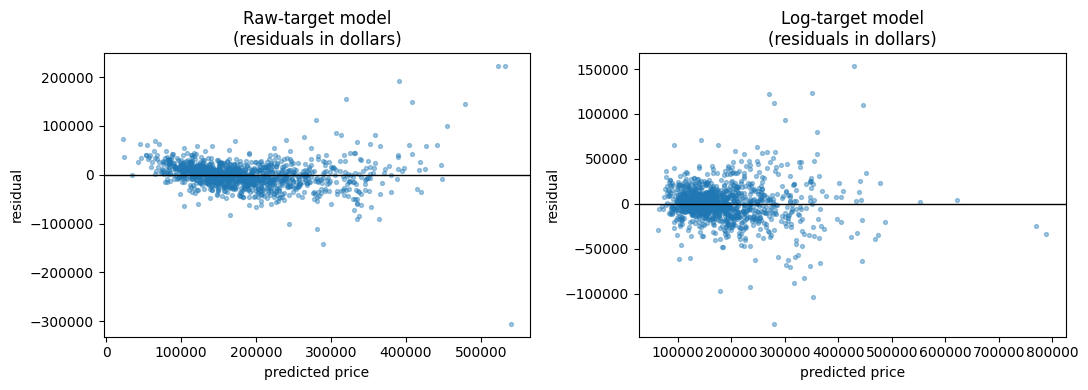

|residual| vs. predicted price, correlation (dollar scale):
  raw-target model: 0.34
  log-target model: 0.34


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(raw_preds, y_train - raw_preds, s=8, alpha=0.4)
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="Raw-target model\n(residuals in dollars)", xlabel="predicted price", ylabel="residual")

axes[1].scatter(log_preds, y_train - log_preds, s=8, alpha=0.4)
axes[1].axhline(0, color="black", lw=1)
axes[1].set(title="Log-target model\n(residuals in dollars)", xlabel="predicted price", ylabel="residual")

plt.tight_layout()
plt.show()

print("|residual| vs. predicted price, correlation (dollar scale):")
print(f"  raw-target model: {np.corrcoef(np.abs(y_train - raw_preds), raw_preds)[0, 1]:.2f}")
print(f"  log-target model: {np.corrcoef(np.abs(y_train - log_preds), log_preds)[0, 1]:.2f}")


Both funnel out in dollar terms, by almost the same amount -- which looks, at first glance, like the log transform did not fix the classic heteroscedasticity problem from `Guide00`'s Stage 8 checklist. It did; we are just checking on the wrong scale. A model fit on `log(SalePrice)` should be judged, for this particular check, on the *log* scale it was actually fit on -- a $700k house being off by $30,000 is a very different mistake from a $100k house being off by $30,000, and converting back to dollars before checking hides that.


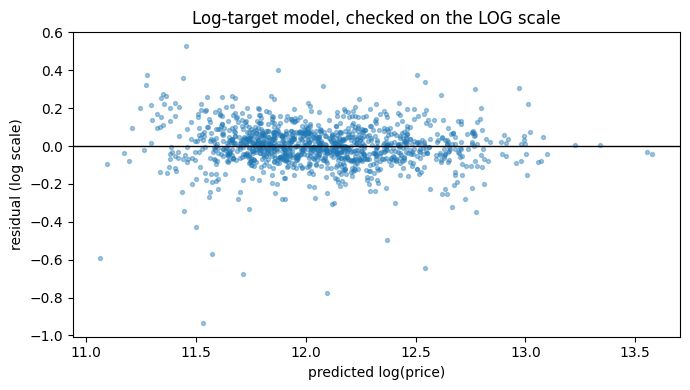

|residual| vs. fitted, correlation (log scale): -0.088


In [8]:
log_resid_scale = cross_val_predict(
    Pipeline([("prep", build_preprocessor(X_train)), ("model", LinearRegression())]),
    X_train, np.log(y_train), cv=kf,
)
log_scale_residuals = np.log(y_train) - log_resid_scale

fig, ax = plt.subplots()
ax.scatter(log_resid_scale, log_scale_residuals, s=8, alpha=0.4)
ax.axhline(0, color="black", lw=1)
ax.set(title="Log-target model, checked on the LOG scale", xlabel="predicted log(price)", ylabel="residual (log scale)")
plt.tight_layout()
plt.show()

print("|residual| vs. fitted, correlation (log scale):",
      round(np.corrcoef(np.abs(log_scale_residuals), log_resid_scale)[0, 1], 3))


On the scale the model actually optimizes, the funnel is gone (correlation near 0, down from 0.34). That is the log transform doing its job -- it controls *relative* (percentage) error, and a bigger *dollar* spread for expensive houses is simply what a well-behaved percentage error looks like once you convert back. Keep both views: the log-scale plot tells you whether the model's assumptions hold; the dollar-scale plot tells you what a user of the model actually experiences.

### A Q-Q plot: are the (log-scale) residuals close to normal?


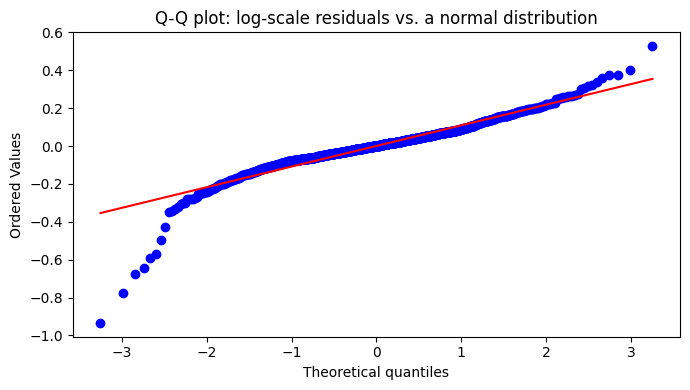

In [9]:
import scipy.stats as stats

fig, ax = plt.subplots()
stats.probplot(log_scale_residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot: log-scale residuals vs. a normal distribution")
plt.tight_layout()
plt.show()


Reasonably close to the line, with some spread at the tails -- normal residuals matter mainly for inference (confidence intervals, p-values), which is not this project's main objective, so we note this and move on.

### The ten worst predictions


In [10]:
worst = (
    pd.DataFrame({"actual": y_train, "predicted": log_preds, "abs_error": np.abs(y_train - log_preds)})
    .join(X_train[["Neighborhood", "SaleCondition", "OverallQual", "GrLivArea"]])
    .sort_values("abs_error", ascending=False)
    .head(10)
)
worst


,actual,predicted,abs_error,Neighborhood,SaleCondition,OverallQual,GrLivArea
755,582933.0,429607.268739,153325.731261,NridgHt,Partial,9,2822.0
1249,147000.0,280532.606166,133532.606166,Somerst,Partial,8,1795.0
171,475000.0,351629.853407,123370.146593,OldTown,Normal,10,3608.0
645,392000.0,270160.495496,121839.504504,StoneBr,Partial,8,1419.0
1113,392500.0,280321.792158,112178.207842,Crawfor,Partial,8,1652.0
985,556581.0,446604.769749,109976.230251,StoneBr,Partial,9,2868.0
1307,250000.0,353298.746087,103298.746087,NWAmes,Normal,7,2784.0
593,82500.0,178982.860428,96482.860428,NWAmes,Family,7,1411.0
727,395000.0,301330.304109,93669.695891,NridgHt,Partial,8,1973.0
552,143000.0,235003.466671,92003.466671,ClearCr,Partial,5,1473.0


In [11]:
print("SaleCondition among the worst 10:", worst["SaleCondition"].value_counts().to_dict())
print("SaleCondition across all training rows:",
      (X_train["SaleCondition"].value_counts(normalize=True) * 100).round(1).to_dict(), "(%)")


SaleCondition among the worst 10: {'Partial': 7, 'Normal': 2, 'Family': 1}
SaleCondition across all training rows: {'Normal': 81.9, 'Partial': 9.4, 'Abnorml': 6.3, 'Family': 1.5, 'Alloca': 0.8, 'AdjLand': 0.1} (%)


`Partial` sales are about 9% of the training data, but 7 of the 10 worst predictions. `Partial` means new construction sold before it was finished -- exactly the pattern `Guide01` found in the two houses removed at Stage 3, just less extreme. The model already has `SaleCondition` as an input (it is one-hot encoded), so this is not a missing feature; it is a missing *interaction*. A plain linear model adds one fixed adjustment for "this sale was Partial," but the way price relates to size and quality may genuinely differ for unfinished new construction -- something only an interaction term (`Guide04`) could capture.

### What if we had skipped the Stage 3 cleaning?

`Guide01` removed two houses over 4,000 sq ft sold as `Partial`, with the reasoning on record. What would this baseline look like if we had kept them in?


In [12]:
raw_dirty = load_ames()
raw_dirty["MSSubClass"] = raw_dirty["MSSubClass"].astype(str)  # keep the dtype fix, skip the row removal

X_train_dirty, _, y_train_dirty, _ = split_ames(raw_dirty)
X_train_dirty = add_engineered_features(X_train_dirty)
print(f"rows: {len(X_train)} (cleaned) vs {len(X_train_dirty)} (giants left in)")

dirty_model = TransformedTargetRegressor(
    regressor=Pipeline([("prep", build_preprocessor(X_train_dirty)), ("model", LinearRegression())]),
    func=np.log, inverse_func=np.exp,
)
dirty_preds = evaluate("log-target model, giants NOT removed", dirty_model, X=X_train_dirty, y=y_train_dirty)
print(f"worst single error: ${np.abs(y_train_dirty - dirty_preds).max():,.0f}")


rows: 1213 (cleaned) vs 1215 (giants left in)
log-target model, giants NOT removed MAE=$  18,890   RMSE=$  63,871   R2= 0.343
worst single error: $1,929,978


Two rows out of 1,215 -- 0.16% of the data -- and $R^2$ collapses from about 0.93 to about 0.34, with one prediction off by close to two million dollars. This is Loop 1 in miniature, and it is why `Guide01` treated those two rows as a Stage 3 decision worth writing down, not a detail to skip past.

### Package it: one `Pipeline`


In [13]:
baseline_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", build_preprocessor(X_train)),
        ("model", LinearRegression()),
    ]),
    func=np.log, inverse_func=np.exp,
)
baseline_model.fit(X_train, y_train)
print("fitted on all", len(X_train), "training rows; ready to hand to Guide04")


fitted on all 1213 training rows; ready to hand to Guide04


---
## What We Hand to `Guide04`

* **The score to beat:** the log-target linear regression, about **\$14,100 MAE** / $R^2 \approx 0.93$ under 5-fold cross-validation.
* **A diagnosis, not just a number:** residuals are well-behaved on the log scale; `Partial` sales are disproportionately mispredicted, which a plain linear model with no interaction terms cannot fully fix.
* **`baseline_model`**, a fitted `Pipeline` other guides can compare against.
* The locked test set, still untouched.


---
## Your Turn

**`CarPrice_Assignment.csv`.** Build the same two baselines -- `DummyRegressor(strategy="mean")` and a plain `LinearRegression` -- on the raw `price` column (start without a preprocessor; the numeric columns alone are enough for a first pass). Plot residuals vs. fitted values. Does this data show the same kind of funnel Ames did before the log transform?


In [14]:
# Your turn: load CarPrice_Assignment.csv and build the two baselines above.
